To demonstrate ``AAPredPlot().eval()``, we build a feature matrix and evaluate a model with a held-out set:

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Build the CPP feature matrix
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

from sklearn.model_selection import train_test_split
X_tr, X_ho, y_tr, y_ho = train_test_split(X, labels, test_size=0.3, random_state=0, stratify=labels)
aapred = aa.AAPred(random_state=42)
df_eval = aapred.eval(X_tr, y_tr, X_holdout=X_ho, labels_holdout=y_ho)

Bars are grouped by metric and colored by model; held-out bars are hatched and a baseline line marks chance:

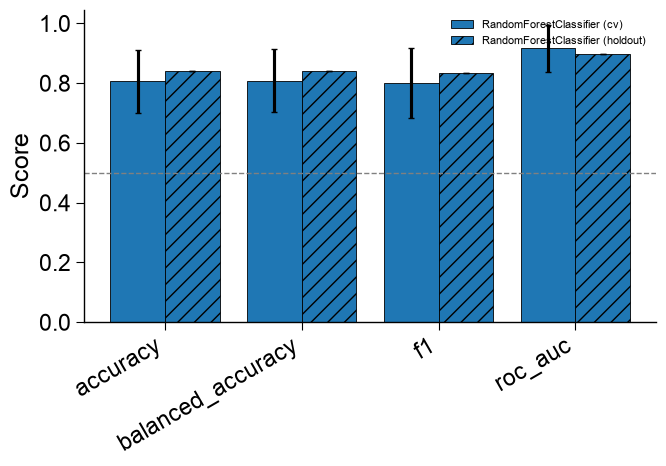

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
aapred_plot = aa.AAPredPlot()
aapred_plot.eval(df_eval, baseline=0.5)
plt.tight_layout()
plt.show()

**Further parameters.** Set the figure size, the y-axis label, and a chance line:

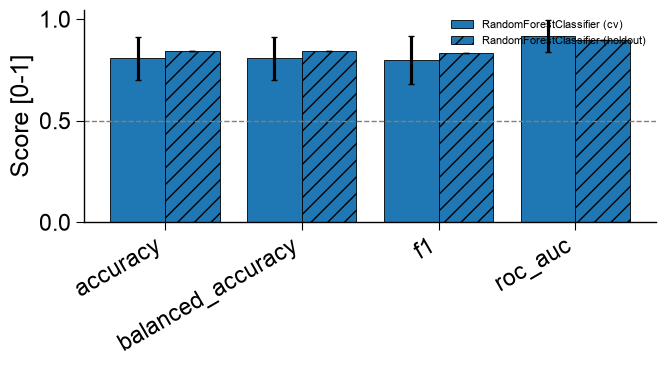

In [3]:
aapred_plot.eval(df_eval, figsize=(7, 4), ylabel="Score [0-1]", baseline=0.5)
plt.tight_layout()
plt.show()

Comparing several **methods**: pass multiple models so each becomes a colored bar (the hue), recolored via ``dict_color``. (To compare CPP *parameter combinations* instead, use the feature-optimization protocol ``aap.find_features`` and its heatmap ``aap.plot_eval``.)

/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programm

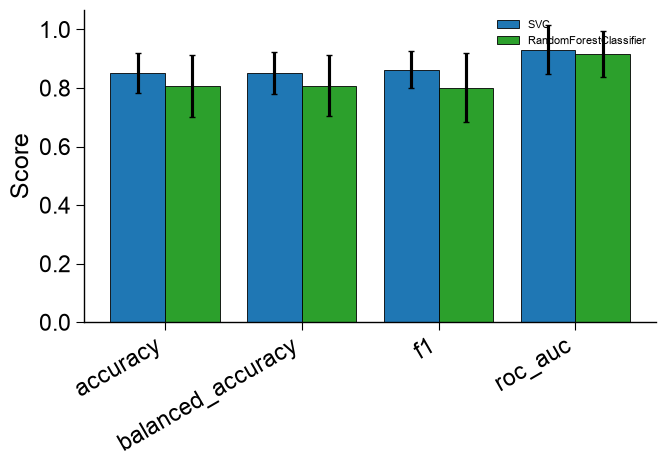

In [4]:
aapred = aa.AAPred(models=["svm", "rf"], random_state=42)
df_eval_multi = aapred.eval(X_tr, y_tr)
model_names = df_eval_multi["model"].unique()
aapred_plot.eval(df_eval_multi,
                 dict_color={model_names[0]: "tab:blue", model_names[1]: "tab:green"})
plt.tight_layout()
plt.show()